# Bayesian Hierarchical Beta Model

This notebook fits the main model for bleaching severity using a Bayesian hierarchical beta regression.

The model estimates ecoregion-specific effects for depth, turbidity, and windspeed while controlling for thermal stress and year-to-year variation.

## 1: Imports

Here I import the packages needed for data preparation, Bayesian modelling, diagnostics, and result tables.

In [1]:
import os
os.environ["PYTENSOR_FLAGS"] = "cxx=,mode=FAST_COMPILE"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import bambi as bmb
import arviz as az

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 123

## 2: Load Dataset

Here I load the cleaned dataset. The code first checks the current folder and then falls back to `/mnt/data/cleaned_data.csv`.

In [2]:
DATA_PATH = "cleaned_data.csv"
df = pd.read_csv(DATA_PATH)

## 3: Validate Dataset

Here I check that the required columns are available and that the model variables have valid values.

In [3]:
required_cols = [
    "Ecoregion_Name",
    "Turbidity",
    "Depth_m",
    "Windspeed",
    "SSTA_DHW",
    "Date_Year",
    "Percent_Bleaching"
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df = df[required_cols].copy()

for col in ["Turbidity", "Depth_m", "Windspeed", "SSTA_DHW", "Date_Year", "Percent_Bleaching"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=required_cols).copy()

df = df[df["Percent_Bleaching"] > 0].copy()

print("Shape:", df.shape)
print("Number of ecoregions:", df["Ecoregion_Name"].nunique())
print("Year range:", int(df["Date_Year"].min()), "to", int(df["Date_Year"].max()))
print("100% bleaching observations:", int((df["Percent_Bleaching"] == 100).sum()))

Shape: (10457, 7)
Number of ecoregions: 7
Year range: 1987 to 2019
100% bleaching observations: 98


## 4: Data Preparation

Here I prepare the outcome for beta regression, log-transform skewed predictors, and standardise the predictors used in the model.

In [4]:
df["Bleaching_prop"] = df["Percent_Bleaching"] / 100

# Beta regression requires the outcome to be strictly inside (0, 1).
n = len(df)
df["Bleaching_beta"] = (df["Bleaching_prop"] * (n - 1) + 0.5) / n

df["log_SSTA_DHW"] = np.log1p(df["SSTA_DHW"])
df["log_Turbidity"] = np.log1p(df["Turbidity"])

scale_cols = ["log_SSTA_DHW", "log_Turbidity", "Depth_m", "Windspeed"]
z_cols = [f"{col}_z" for col in scale_cols]

scaler = StandardScaler()
df[z_cols] = scaler.fit_transform(df[scale_cols])

df["Ecoregion_Name"] = df["Ecoregion_Name"].astype("category")
df["Date_Year"] = df["Date_Year"].astype(int).astype("category")

prep_summary = pd.DataFrame({
    "original_variable": scale_cols,
    "standardised_variable": z_cols,
    "mean_before_scaling": scaler.mean_,
    "sd_before_scaling": scaler.scale_
})

prep_summary

,original_variable,standardised_variable,mean_before_scaling,sd_before_scaling
0,log_SSTA_DHW,log_SSTA_DHW_z,1.029214,0.899333
1,log_Turbidity,log_Turbidity_z,0.065664,0.043036
2,Depth_m,Depth_m_z,8.536085,4.820028
3,Windspeed,Windspeed_z,4.718275,1.939361


## 5: Main Model

Here I fit the Bayesian hierarchical beta regression.

The model uses:

- a beta likelihood for proportional bleaching severity
- a fixed effect for thermal stress
- ecoregion-specific intercepts
- ecoregion-specific slopes for turbidity, depth, and windspeed
- a year random intercept

Model formula:

```text
Bleaching_beta ~ log_SSTA_DHW_z
               + (1 + log_Turbidity_z + Depth_m_z + Windspeed_z | Ecoregion_Name)
               + (1 | Date_Year)
```

In [5]:
formula = """
Bleaching_beta ~ log_SSTA_DHW_z
               + (1 + log_Turbidity_z + Depth_m_z + Windspeed_z | Ecoregion_Name)
               + (1 | Date_Year)
"""

model = bmb.Model(
    formula=formula,
    data=df,
    family="beta"
)

model

       Formula: 
Bleaching_beta ~ log_SSTA_DHW_z
               + (1 + log_Turbidity_z + Depth_m_z + Windspeed_z | Ecoregion_Name)
               + (1 | Date_Year)

        Family: beta
          Link: mu = logit
  Observations: 10457
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 0.0, sigma: 2.5)
            log_SSTA_DHW_z ~ Normal(mu: 0.0, sigma: 2.5)
        
        Group-level effects
            1|Ecoregion_Name ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
            log_Turbidity_z|Ecoregion_Name ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
            Depth_m_z|Ecoregion_Name ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
            Windspeed_z|Ecoregion_Name ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
            1|Date_Year ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 2.5))
        
        Auxiliary parameters
            kappa ~ HalfCauchy(beta: 1.0)

## 6: Fit Model

Here I sample from the posterior distribution. The settings below are conservative enough for a hierarchical model but can be reduced if runtime is too long.

In [6]:
idata = model.fit(
    draws=1500,
    tune=1000,
    chains=4,
    target_accept=0.9,
    random_seed=123,
    inference_method="nuts_numpyro"
)


/Users/tom/venv/lib/python3.11/site-packages/bambi/backend/pymc.py:124: FutureWarning: 'nuts_numpyro' has been replaced by 'numpyro' and will be removed in a future release.
  warnings.warn(


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


## 7: Posterior Summary

Here I inspect the posterior summary. The most important diagnostics are `r_hat` and effective sample size.

In [7]:
summary = az.summary(idata, round_to=3)
summary

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.677,0.188,-2.039,-1.331,0.005,0.004,1356.192,1937.596,1.002
log_SSTA_DHW_z,0.132,0.012,0.112,0.155,0.000,0.000,8663.138,4168.778,1.002
kappa,2.617,0.037,2.549,2.687,0.000,0.001,8119.359,3940.969,1.001
1|Ecoregion_Name_sigma,0.429,0.167,0.194,0.724,0.004,0.005,2060.243,2581.178,1.002
log_Turbidity_z|Ecoregion_Name_sigma,0.093,0.037,0.037,0.161,0.001,0.001,2356.046,3464.451,1.001
...,...,...,...,...,...,...,...,...,...
1|Date_Year[2015],0.265,0.084,0.110,0.423,0.002,0.001,1241.224,2877.941,1.001
1|Date_Year[2016],0.021,0.089,-0.149,0.187,0.002,0.001,1315.712,2368.931,1.000
1|Date_Year[2017],-0.021,0.095,-0.196,0.162,0.003,0.001,1412.678,3105.620,1.000
1|Date_Year[2018],-0.555,0.118,-0.781,-0.337,0.002,0.002,2313.332,3438.779,1.000


## 8: Diagnostics

Here I check convergence and posterior predictive fit.

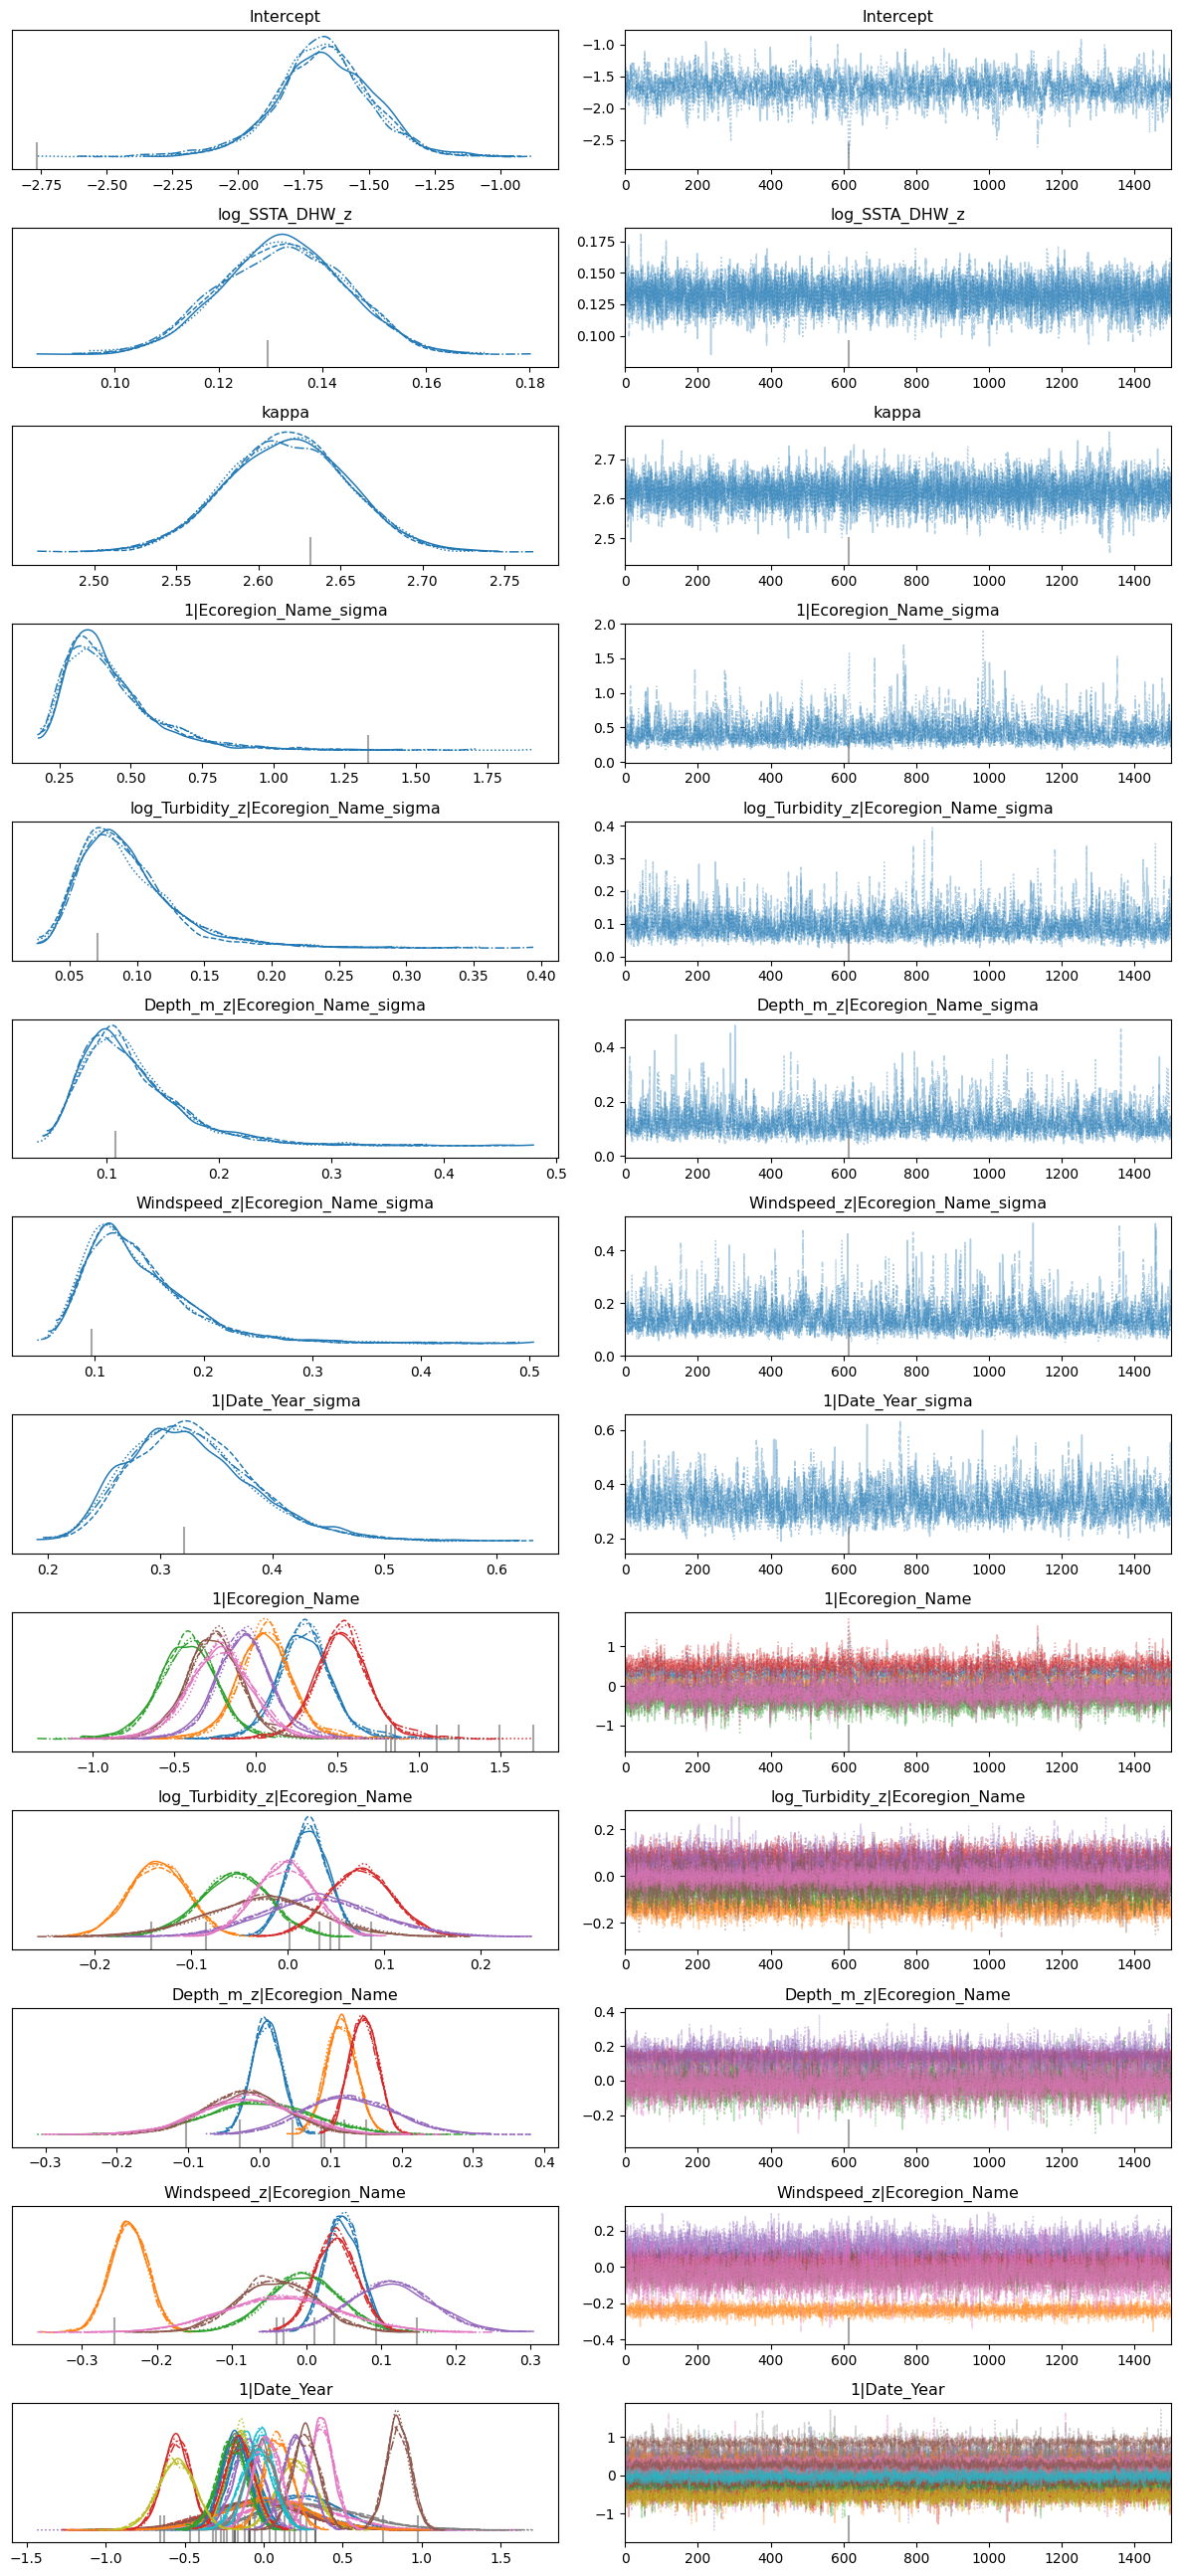

In [8]:
az.plot_trace(idata, compact=True)
plt.tight_layout()
plt.show()

/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


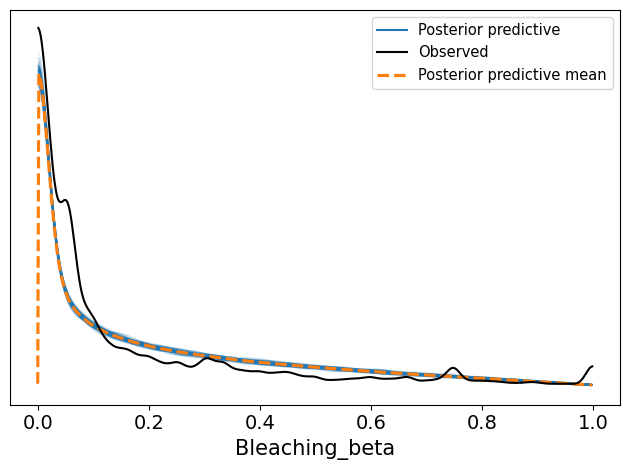

In [9]:
# Posterior predictive checks.
model.predict(idata, kind="pps", inplace=True)

az.plot_ppc(idata, num_pp_samples=100)
plt.tight_layout()
plt.show()

/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:922: FutureWarning: 'pps' has been replaced by 'response' and is not going to work in the future
  warnings.warn(


<Figure size 800x500 with 0 Axes>

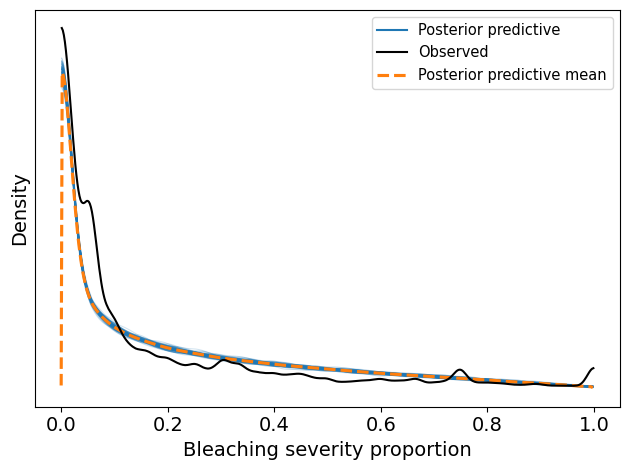

In [19]:
# Posterior predictive checks.
model.predict(idata, kind="pps", inplace=True)

plt.figure(figsize=(8, 5))

az.plot_ppc(idata, num_pp_samples=100)

plt.xlabel("Bleaching severity proportion", fontsize=14)
plt.ylabel("Density", fontsize=14)

# Optional: remove title
plt.title("")

plt.tight_layout()
plt.show()

## 9: Helper Functions for Predictions

Here I define helper functions used to extract posterior mean predictions and compute marginal effects.

In [10]:
def _find_response_mean_var(pred_idata):
    """Find the posterior variable containing the expected response mean."""
    candidate_names = ["mu", "mean", "p"]
    posterior_vars = list(pred_idata.posterior.data_vars)

    for name in candidate_names:
        if name in posterior_vars:
            return name

    for name in posterior_vars:
        dims = pred_idata.posterior[name].dims
        if any(dim not in ["chain", "draw"] for dim in dims):
            return name

    raise ValueError(f"Could not find response mean variable. Available posterior variables: {posterior_vars}")


def posterior_mu(model, idata, new_data):
    """Return posterior draws of expected bleaching probability for new data."""
    pred_idata = model.predict(
        idata,
        data=new_data,
        kind="mean",
        inplace=False
    )

    mean_var = _find_response_mean_var(pred_idata)
    mu = pred_idata.posterior[mean_var]
    return mu


def average_over_observations(da):
    """Average a posterior prediction array over its observation dimension."""
    obs_dims = [dim for dim in da.dims if dim not in ["chain", "draw"]]
    if len(obs_dims) == 0:
        return da
    return da.mean(dim=obs_dims)


def hdi_from_draws(draws, hdi_prob=0.95):
    """Compute HDI lower and upper bounds from an xarray draw object."""
    hdi = az.hdi(draws, hdi_prob=hdi_prob)
    values = np.asarray(hdi.to_array()).reshape(-1)
    return float(values[0]), float(values[1])

## 10: Average Marginal Effects

Here I compute average marginal effects for a +1 standard deviation increase in each environmental predictor within each ecoregion.

Effects are reported in percentage points.

In [11]:
ame_predictors = {
    "Depth_m": "Depth_m_z",
    "log_Turbidity": "log_Turbidity_z",
    "Windspeed": "Windspeed_z"
}

ame_rows = []

for eco, sub in df.groupby("Ecoregion_Name", observed=True):
    base = sub.copy()
    mu_base = posterior_mu(model, idata, base)
    mu_base_avg = average_over_observations(mu_base)

    baseline_draws_pp = mu_base_avg * 100
    baseline_mean = float(baseline_draws_pp.mean())

    for label, pred_col in ame_predictors.items():
        changed = base.copy()
        changed[pred_col] = changed[pred_col] + 1

        mu_changed = posterior_mu(model, idata, changed)
        mu_changed_avg = average_over_observations(mu_changed)

        effect_draws_pp = (mu_changed_avg - mu_base_avg) * 100

        hdi_low, hdi_high = hdi_from_draws(effect_draws_pp, hdi_prob=0.95)
        p_positive = float((effect_draws_pp > 0).mean())
        p_negative = float((effect_draws_pp < 0).mean())

        ame_rows.append({
            "Ecoregion": eco,
            "Predictor": label,
            "Baseline_%": baseline_mean,
            "AME_pp": float(effect_draws_pp.mean()),
            "HDI_2.5": hdi_low,
            "HDI_97.5": hdi_high,
            "P(AME > 0)": p_positive,
            "P(AME < 0)": p_negative
        })

ame_long = pd.DataFrame(ame_rows)

ame_long.round(3)

/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mean' has been replaced by 'response_params' and is not going to work in the future
  warnings.warn(
/Users/tom/venv/lib/python3.11/site-packages/bambi/models.py:915: FutureWarning: 'mea

,Ecoregion,Predictor,Baseline_%,AME_pp,HDI_2.5,HDI_97.5,P(AME > 0),P(AME < 0)
0,Bahamas and Florida Keys,Depth_m,23.028,0.179,-0.544,0.844,0.686,0.314
1,Bahamas and Florida Keys,log_Turbidity,23.028,0.365,-0.345,1.017,0.849,0.151
2,Bahamas and Florida Keys,Windspeed,23.028,0.855,0.120,1.658,0.987,0.013
3,Belize and west Caribbean,Depth_m,25.451,2.111,1.339,2.887,1.000,0.000
4,Belize and west Caribbean,log_Turbidity,25.451,-2.339,-3.282,-1.356,0.000,1.000
5,Belize and west Caribbean,Windspeed,25.451,-4.023,-4.785,-3.256,0.000,1.000
6,Central and northern Great Barrier Reef,Depth_m,12.639,0.022,-1.571,1.677,0.498,0.502
7,Central and northern Great Barrier Reef,log_Turbidity,12.639,-0.587,-1.317,0.181,0.056,0.944
8,Central and northern Great Barrier Reef,Windspeed,12.639,-0.028,-1.067,0.940,0.472,0.528
9,Hispaniola Puerto Rico and Lesser Antilles,Depth_m,33.239,3.009,2.243,3.784,1.000,0.000


## 11: AME Summary Table

Here I format the marginal effects in a compact ecoregion-by-predictor table. The dominant predictor is the predictor with the largest absolute AME within each ecoregion.

In [20]:
ame_wide = (
    ame_long
    .pivot(index="Ecoregion", columns="Predictor", values="AME_pp")
    .reset_index()
)

baseline = (
    ame_long
    .groupby("Ecoregion", as_index=False)["Baseline_%"]
    .first()
)

ame_table = baseline.merge(ame_wide, on="Ecoregion")

predictor_cols = ["Depth_m", "log_Turbidity", "Windspeed"]

# Add credibility information
credibility = ame_long.copy()

credibility["credible"] = (
    (credibility["P(AME > 0)"] >= 0.95) |
    (credibility["P(AME < 0)"] >= 0.95)
)

credible_wide = (
    credibility
    .pivot(index="Ecoregion", columns="Predictor", values="credible")
    .reset_index()
)

# Rename credibility columns so they do not clash
credible_wide = credible_wide.rename(columns={
    "Depth_m": "Depth_m_credible",
    "log_Turbidity": "log_Turbidity_credible",
    "Windspeed": "Windspeed_credible"
})

ame_table = ame_table.merge(credible_wide, on="Ecoregion")

# Dominant predictor should only be selected among credible effects
def get_dominant_credible(row):
    credible_effects = {}

    for pred in predictor_cols:
        if row[f"{pred}_credible"]:
            credible_effects[pred] = abs(row[pred])

    if len(credible_effects) == 0:
        return "None"

    return max(credible_effects, key=credible_effects.get)

ame_table["Dominant"] = ame_table.apply(get_dominant_credible, axis=1)

# Clean display names
ame_table["Dominant"] = ame_table["Dominant"].replace({
    "Depth_m": "Depth",
    "log_Turbidity": "Turbidity",
    "Windspeed": "Windspeed",
    "None": "None"
})

ame_table = ame_table[
    [
        "Ecoregion",
        "Baseline_%",
        "Depth_m",
        "log_Turbidity",
        "Windspeed",
        "Depth_m_credible",
        "log_Turbidity_credible",
        "Windspeed_credible",
        "Dominant"
    ]
]

ame_table.round({
    "Baseline_%": 1,
    "Depth_m": 2,
    "log_Turbidity": 2,
    "Windspeed": 2
})

,Ecoregion,Baseline_%,Depth_m,log_Turbidity,Windspeed,Depth_m_credible,log_Turbidity_credible,Windspeed_credible,Dominant
0,Bahamas and Florida Keys,23.0,0.18,0.37,0.86,False,False,True,Windspeed
1,Belize and west Caribbean,25.5,2.11,-2.34,-4.02,True,True,True,Windspeed
2,Central and northern Great Barrier Reef,12.6,0.02,-0.59,-0.03,False,False,False,None
3,Hispaniola Puerto Rico and Lesser Antilles,33.2,3.01,1.55,0.80,True,True,False,Depth
4,Jamaica,15.8,1.71,0.45,1.53,True,False,True,Depth
5,Sulu Sea,12.8,-0.20,-0.27,-0.41,False,False,False,None
6,Sunda Shelf south-east Asia,13.8,-0.19,-0.03,-0.34,False,False,False,None


In [29]:
ame_table_display = ame_table.rename(columns={
    "Depth_m": "Depth",
    "log_Turbidity": "Turbidity",
    "Depth_m_credible": "Depth_credible",
    "log_Turbidity_credible": "Turbidity_credible",
    "Dominant": "Dominant Predictor"
})


def style_ame_table(row):
    styles = []
    effect_cols = ["Depth", "Turbidity", "Windspeed"]

    max_abs = max(abs(row[col]) for col in effect_cols)

    for col in row.index:
        if col in effect_cols:
            value = row[col]
            intensity = abs(value) / max_abs if max_abs != 0 else 0

            alpha = 0.15 + 0.40 * intensity
            credible = row[f"{col}_credible"]
            font_weight = "bold" if credible else "normal"

            if value > 0:
                styles.append(
                    f"background-color: rgba(30, 160, 90, {alpha}); "
                    f"color: white; font-weight: {font_weight};"
                )
            elif value < 0:
                styles.append(
                    f"background-color: rgba(200, 70, 40, {alpha}); "
                    f"color: white; font-weight: {font_weight};"
                )
            else:
                styles.append(f"font-weight: {font_weight};")

        elif col.endswith("_credible"):
            styles.append("display: none;")

        else:
            styles.append("")

    return styles

display_cols = [
    "Ecoregion",
    "Baseline_%",
    "Depth",
    "Turbidity",
    "Windspeed",
    "Depth_credible",
    "Turbidity_credible",
    "Windspeed_credible",
    "Dominant Predictor"
]

ame_table_display = ame_table_display[display_cols]

styled_table = (
    ame_table_display
    .style
    .hide(axis="index")
    .hide(
        subset=[
            "Depth_credible",
            "Turbidity_credible",
            "Windspeed_credible"
        ],
        axis="columns"
    )
    .apply(style_ame_table, axis=1)
    .format({
        "Baseline_%": "{:.1f}%",
        "Depth": "{:+.2f}",
        "Turbidity": "{:+.2f}",
        "Windspeed": "{:+.2f}"
    })
)

styled_table

Ecoregion,Baseline_%,Depth,Turbidity,Windspeed,Dominant Predictor
Bahamas and Florida Keys,23.0%,+0.18,+0.37,+0.86,Windspeed
Belize and west Caribbean,25.5%,+2.11,-2.34,-4.02,Windspeed
Central and northern Great Barrier Reef,12.6%,+0.02,-0.59,-0.03,None
Hispaniola Puerto Rico and Lesser Antilles,33.2%,+3.01,+1.55,+0.80,Depth
Jamaica,15.8%,+1.71,+0.45,+1.53,Depth
Sulu Sea,12.8%,-0.20,-0.27,-0.41,None
Sunda Shelf south-east Asia,13.8%,-0.19,-0.03,-0.34,None


## 12: Credibility Filter

Here I classify each AME based on the posterior probability of its direction.

The rule is:

- `credible positive` if P(AME > 0) ≥ 0.95
- `credible negative` if P(AME < 0) ≥ 0.95
- `uncertain` otherwise

In [14]:
credibility = ame_long.copy()

conditions = [
    credibility["P(AME > 0)"] >= 0.95,
    credibility["P(AME < 0)"] >= 0.95
]
choices = ["credible positive", "credible negative"]

credibility["Direction"] = np.select(conditions, choices, default="uncertain")

credibility_table = credibility[[
    "Ecoregion",
    "Predictor",
    "AME_pp",
    "HDI_2.5",
    "HDI_97.5",
    "P(AME > 0)",
    "P(AME < 0)",
    "Direction"
]].sort_values(["Ecoregion", "Predictor"])

credibility_table.round(3)

,Ecoregion,Predictor,AME_pp,HDI_2.5,HDI_97.5,P(AME > 0),P(AME < 0),Direction
0,Bahamas and Florida Keys,Depth_m,0.179,-0.544,0.844,0.686,0.314,uncertain
2,Bahamas and Florida Keys,Windspeed,0.855,0.120,1.658,0.987,0.013,credible positive
1,Bahamas and Florida Keys,log_Turbidity,0.365,-0.345,1.017,0.849,0.151,uncertain
3,Belize and west Caribbean,Depth_m,2.111,1.339,2.887,1.000,0.000,credible positive
5,Belize and west Caribbean,Windspeed,-4.023,-4.785,-3.256,0.000,1.000,credible negative
4,Belize and west Caribbean,log_Turbidity,-2.339,-3.282,-1.356,0.000,1.000,credible negative
6,Central and northern Great Barrier Reef,Depth_m,0.022,-1.571,1.677,0.498,0.502,uncertain
8,Central and northern Great Barrier Reef,Windspeed,-0.028,-1.067,0.940,0.472,0.528,uncertain
7,Central and northern Great Barrier Reef,log_Turbidity,-0.587,-1.317,0.181,0.056,0.944,uncertain
9,Hispaniola Puerto Rico and Lesser Antilles,Depth_m,3.009,2.243,3.784,1.000,0.000,credible positive


### Thesis tables

In [31]:
table1 = (
    ame_table[["Ecoregion", "Baseline_%"]]
    .sort_values("Baseline_%", ascending=False)
    .rename(columns={
        "Baseline_%": "Baseline Bleaching (%)"
    })
)

table1["Baseline Bleaching (%)"] = (
    table1["Baseline Bleaching (%)"]
    .round(1)
    .astype(str) + "%"
)

(
    table1
    .style
    .hide(axis="index")
)

Ecoregion,Baseline Bleaching (%)
Hispaniola Puerto Rico and Lesser Antilles,33.2%
Belize and west Caribbean,25.5%
Bahamas and Florida Keys,23.0%
Jamaica,15.8%
Sunda Shelf south-east Asia,13.8%
Sulu Sea,12.8%
Central and northern Great Barrier Reef,12.6%


In [39]:
table2 = ame_long.copy()

# Create direction labels
conditions = [
    table2["P(AME > 0)"] >= 0.95,
    table2["P(AME < 0)"] >= 0.95
]

choices = [
    "credible positive",
    "credible negative"
]

table2["Credibility"] = np.select(
    conditions,
    choices,
    default="uncertain"
)

# Create formatted HDI column
table2["95% HDI"] = (
    "[" +
    table2["HDI_2.5"].round(2).astype(str) +
    ", " +
    table2["HDI_97.5"].round(2).astype(str) +
    "]"
)

# Rename predictors for cleaner presentation
table2["Predictor"] = table2["Predictor"].replace({
    "Depth_m": "Depth",
    "log_Turbidity": "Turbidity",
    "Windspeed": "Windspeed"
})

# Keep only needed columns
table2 = table2[
    [
        "Ecoregion",
        "Predictor",
        "AME_pp",
        "95% HDI",
        "Credibility"
    ]
]

# Sort within ecoregions by absolute effect size
table2["abs_AME"] = table2["AME_pp"].abs()

table2 = (
    table2
    .sort_values(
        by=["Ecoregion", "abs_AME"],
        ascending=[True, False]
    )
    .drop(columns="abs_AME")
)

table2 = table2.rename(columns={
    "AME_pp": "AME (pp)"
})

table2["AME (pp)"] = table2["AME (pp)"].map(lambda x: f"{x:+.2f}")

table2.reset_index(drop=True)

(
    table2
    .style
    .hide(axis="index")
)

Ecoregion,Predictor,AME (pp),95% HDI,Credibility
Bahamas and Florida Keys,Windspeed,+0.86,"[0.12, 1.66]",credible positive
Bahamas and Florida Keys,Turbidity,+0.37,"[-0.34, 1.02]",uncertain
Bahamas and Florida Keys,Depth,+0.18,"[-0.54, 0.84]",uncertain
Belize and west Caribbean,Windspeed,-4.02,"[-4.79, -3.26]",credible negative
Belize and west Caribbean,Turbidity,-2.34,"[-3.28, -1.36]",credible negative
Belize and west Caribbean,Depth,+2.11,"[1.34, 2.89]",credible positive
Central and northern Great Barrier Reef,Turbidity,-0.59,"[-1.32, 0.18]",uncertain
Central and northern Great Barrier Reef,Windspeed,-0.03,"[-1.07, 0.94]",uncertain
Central and northern Great Barrier Reef,Depth,+0.02,"[-1.57, 1.68]",uncertain
Hispaniola Puerto Rico and Lesser Antilles,Depth,+3.01,"[2.24, 3.78]",credible positive


In [41]:
# Keep only credible effects
credible_effects = ame_long[
    (ame_long["P(AME > 0)"] >= 0.95) |
    (ame_long["P(AME < 0)"] >= 0.95)
].copy()

# Determine direction
credible_effects["Direction"] = np.where(
    credible_effects["AME_pp"] > 0,
    "Positive",
    "Negative"
)

# Rename predictors
credible_effects["Predictor"] = credible_effects["Predictor"].replace({
    "Depth_m": "Depth",
    "log_Turbidity": "Turbidity",
    "Windspeed": "Windspeed"
})

# Find dominant predictor within each ecoregion
credible_effects["abs_AME"] = credible_effects["AME_pp"].abs()

dominant = (
    credible_effects
    .sort_values("abs_AME", ascending=False)
    .groupby("Ecoregion", as_index=False)
    .first()
)

dominant = dominant[
    [
        "Ecoregion",
        "Predictor",
        "Direction",
        "AME_pp"
    ]
]

dominant = dominant.rename(columns={
    "Predictor": "Dominant Predictor",
    "AME_pp": "AME (pp)"
})

dominant["AME (pp)"] = dominant["AME (pp)"].map(
    lambda x: f"{x:+.2f}"
)

# Add regions with no credible effects
all_regions = set(ame_long["Ecoregion"].unique())
dominant_regions = set(dominant["Ecoregion"].unique())

missing_regions = all_regions - dominant_regions

missing_df = pd.DataFrame({
    "Ecoregion": list(missing_regions),
    "Dominant Predictor": "None",
    "Direction": "—",
    "AME (pp)": "—"
})

table3 = pd.concat(
    [dominant, missing_df],
    ignore_index=True
)

# Sort alphabetically
table3 = table3.sort_values("Ecoregion")

(
    table3
    .style
    .hide(axis="index")
)

Ecoregion,Dominant Predictor,Direction,AME (pp)
Bahamas and Florida Keys,Windspeed,Positive,+0.86
Belize and west Caribbean,Windspeed,Negative,-4.02
Central and northern Great Barrier Reef,None,—,—
Hispaniola Puerto Rico and Lesser Antilles,Depth,Positive,+3.01
Jamaica,Depth,Positive,+1.71
Sulu Sea,None,—,—
Sunda Shelf south-east Asia,None,—,—
